# HAH913E – Physical Activity Assignment 00

**Team members:** Thomas Vigneau-Sugar

**GitHub repository:** [Git-Series-00](https://github.com/tom22121/Git-Series-00)

## Load the accelerometer data

The file `0_z.csv` contains the time in seconds and the acceleration measured along the three axes (x, y, z) in g.

In [33]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt("0_z.csv", delimiter=",", skiprows=2)

print(data[:5])
print("Data shape:", data.shape)

[[ 0.     -0.0938 -0.0156  0.9531]
 [ 0.02   -0.0938 -0.0156  0.9531]
 [ 0.04   -0.0938 -0.0156  0.9531]
 [ 0.06   -0.0938 -0.0156  0.9531]
 [ 0.08   -0.0938 -0.0156  0.9531]]
Data shape: (21000, 4)


## Sampling frequency

The sampling frequency can be calculated from the time difference between two consecutive samples.

In [34]:
dt = data[1, 0] - data[0, 0]
fs = 1 / dt

print("Time step:", dt, "s")
print("Sampling frequency:", fs, "Hz")

Time step: 0.02 s
Sampling frequency: 50.0 Hz


## ENMO calculation

ENMO (Euclidean Norm Minus One) is calculated from the acceleration measured along the three axes:

$$
ENMO = \sqrt{x^2 + y^2 + z^2} - 1
$$

In [35]:
def calculate_enmo(x, y, z):
    magnitude = np.sqrt(x**2 + y**2 + z**2)
    enmo = magnitude - 1
    return enmo
x = data[:, 1]
y = data[:, 2]
z = data[:, 3]

enmo = calculate_enmo(x, y, z)

print(enmo[:5])

[-0.04216838 -0.04216838 -0.04216838 -0.04216838 -0.04216838]


## ENMO over time

Before integrating ENMO over epochs, the ENMO signal is plotted over the complete recording.

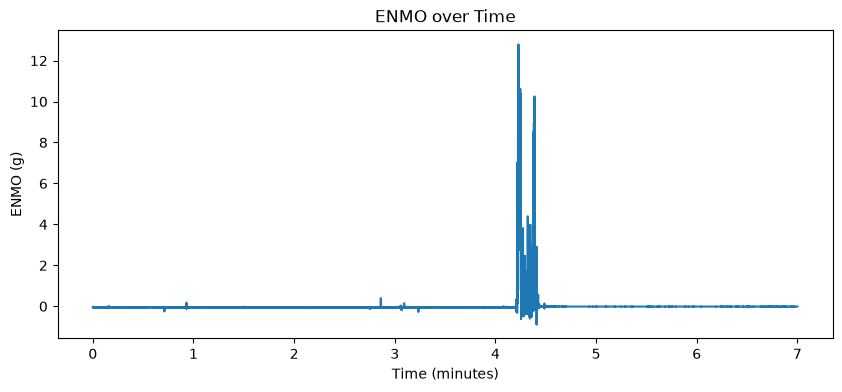

In [36]:
time = data[:, 0]
time_minutes = time / 60

plt.figure(figsize=(10, 4))
plt.plot(time_minutes, enmo)
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.title("ENMO over Time")
plt.show()

## ENMO integration over epochs

To help structure the integration function, I used the following Copilot prompt:

> "Using NumPy, suggest a simple Python function to integrate an ENMO signal over fixed epoch durations. The function should take the ENMO array, the epoch duration in seconds, and the sampling frequency as inputs."

Copilot suggested dividing the signal into complete epochs and summing the ENMO values within each epoch. I reviewed the suggestion before adapting it to the calculation used in this notebook.

After reviewing Copilot's suggestion, I changed two parts of the proposed function. I used a simple loop over the epochs instead of reshaping the array, because this makes the different steps of the calculation easier to follow. I also converted the integrated values from g·s to g·min by dividing by 60.

In [37]:
def integrate_enmo(enmo, epoch_seconds, fs):
    samples_per_epoch = int(epoch_seconds * fs)
    n_epochs = len(enmo) // samples_per_epoch

    integrated = []

    for i in range(n_epochs):
        start = i * samples_per_epoch
        end = start + samples_per_epoch
        epoch = enmo[start:end]

        integrated.append(np.sum(epoch) / (fs * 60))

    return np.array(integrated)

## ENMO integrated over 10 s epochs

The ENMO signal is divided into 10-second epochs. The values within each complete epoch are integrated and converted from g·s to g·min.

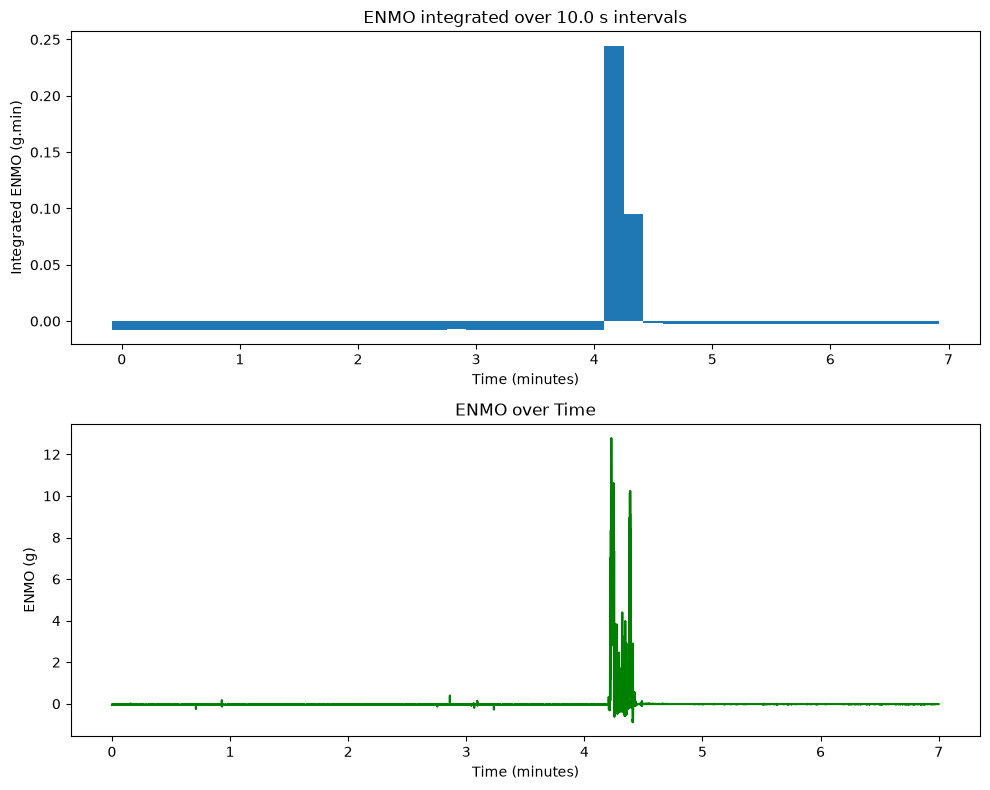

In [43]:
epoch_seconds = 10

integrated_10 = integrate_enmo(enmo, epoch_seconds, fs)
time_10 = np.arange(len(integrated_10)) * epoch_seconds / 60

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.bar(time_10, integrated_10, width=epoch_seconds/60)
plt.xlabel("Time (minutes)")
plt.ylabel("Integrated ENMO (g.min)")
plt.title("ENMO integrated over 10.0 s intervals")

plt.subplot(2, 1, 2)
plt.plot(time_minutes, enmo, color="green")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.title("ENMO over Time")

plt.tight_layout()
plt.show()

## ENMO integrated over 30 s epochs

The same integration method is now applied using 30-second epochs.

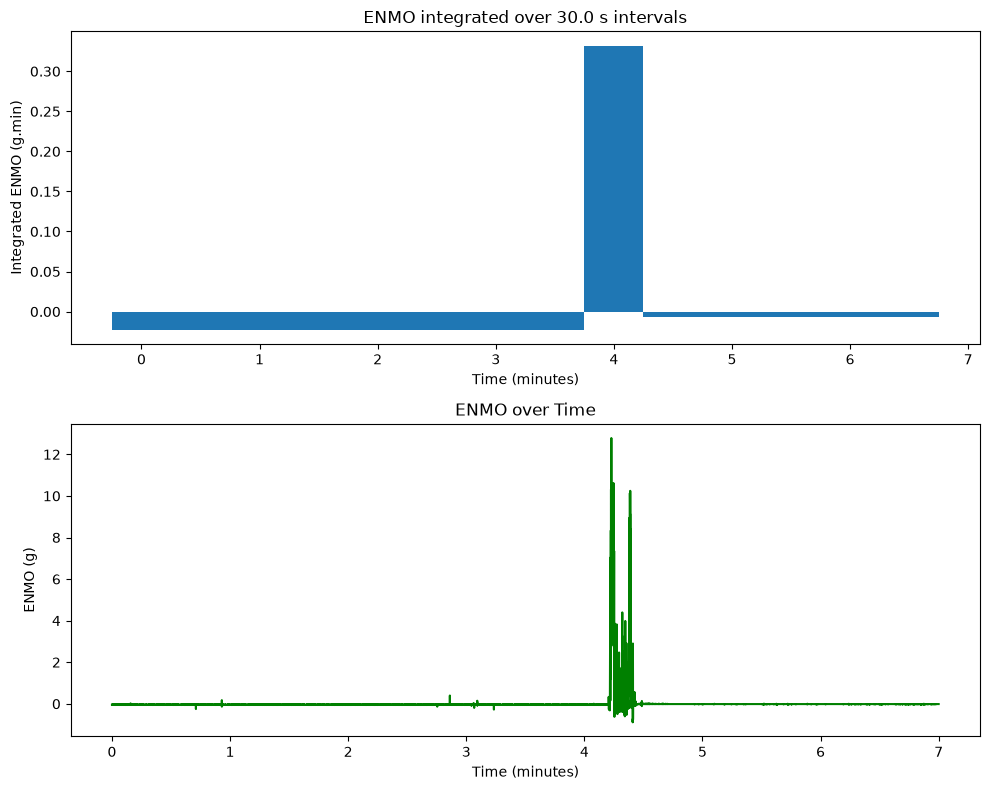

In [45]:
epoch_seconds = 30

integrated_30 = integrate_enmo(enmo, epoch_seconds, fs)
time_30 = np.arange(len(integrated_30)) * epoch_seconds / 60

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.bar(time_30, integrated_30, width=epoch_seconds/60)
plt.xlabel("Time (minutes)")
plt.ylabel("Integrated ENMO (g.min)")
plt.title("ENMO integrated over 30.0 s intervals")

plt.subplot(2, 1, 2)
plt.plot(time_minutes, enmo,color="green")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.title("ENMO over Time")

plt.tight_layout()
plt.show()

## ENMO integrated over 60 s epochs

Finally, the ENMO signal is integrated using 60-second epochs.

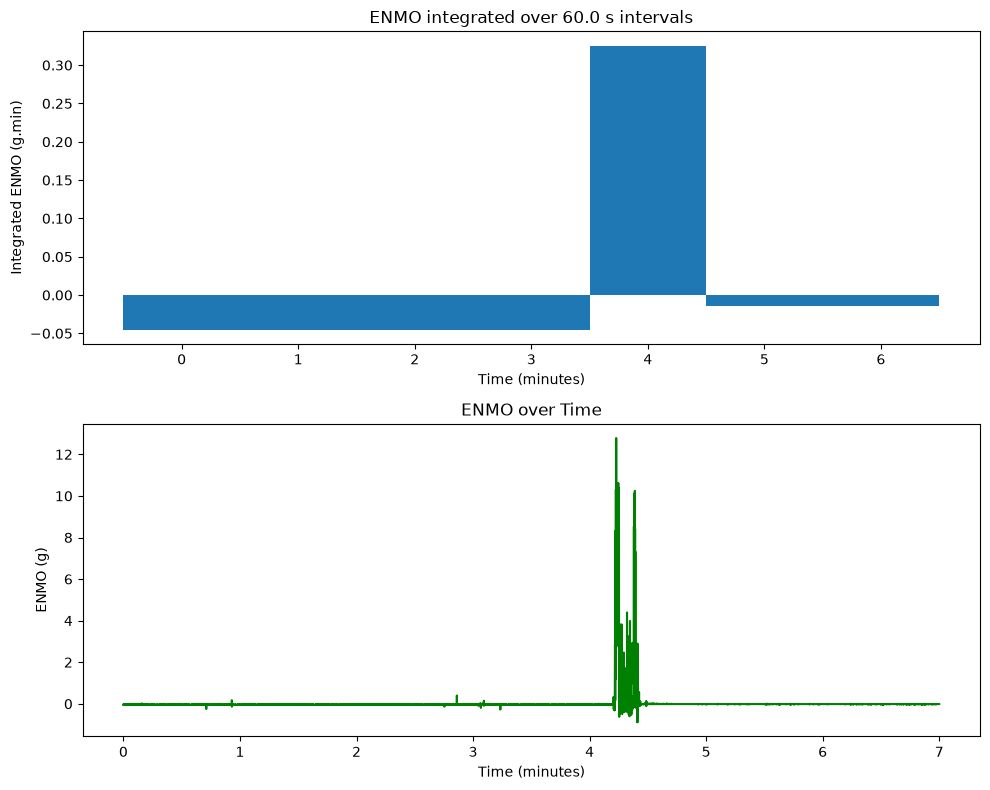

In [46]:
epoch_seconds = 60

integrated_60 = integrate_enmo(enmo, epoch_seconds, fs)
time_60 = np.arange(len(integrated_60)) * epoch_seconds / 60

plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.bar(time_60, integrated_60, width=epoch_seconds/60)
plt.xlabel("Time (minutes)")
plt.ylabel("Integrated ENMO (g.min)")
plt.title("ENMO integrated over 60.0 s intervals")

plt.subplot(2, 1, 2)
plt.plot(time_minutes, enmo, color="green")
plt.xlabel("Time (minutes)")
plt.ylabel("ENMO (g)")
plt.title("ENMO over Time")

plt.tight_layout()
plt.show()